# Figure 5 - Does Increasing Width Preserve Plasticity?

This notebook sweeps MLP and CNN widths, trains each DQN agent on a classification MDP, and measures final plasticity loss relative to the matching initial checkpoint.

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
OUTPUT_ROOT.mkdir(exist_ok=True)
MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

## Imports

In [2]:
import pandas as pd

from experiments.section5.figure5_width_sweep import (
    make_smoke_configs,
    make_width_sweep_configs,
    run_width_sweep,
    plot_width_sweep,
)
from experiments.section5.dqn_classification import DEVICE

DEVICE

device(type='cpu')

## Select Widths

For MLPs, `width` is the hidden-layer width.  For CNNs, `width` is the convolution channel count and the fully connected width is set to `4 * width` in the sweep helper.

In [3]:
configs = make_smoke_configs(data_root=str(DATA_ROOT), download=False)

pd.DataFrame([c.__dict__ for c in configs])

,seed,data_root,download,observation_space,environment,architecture,hidden_dim,cnn_channels,cnn_fc_dim,gamma,...,use_layernorm,spectral_norm,shrink_perturb_every,shrink,perturb,reset_last_layer_every,width,probe_steps,num_probe_tasks,probe_batch_size
0,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,32,64,256,0.99,...,False,False,None,0.4,0.1,None,32,50,2,128
1,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,64,64,256,0.99,...,False,False,None,0.4,0.1,None,64,50,2,128
2,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,cnn,512,16,64,0.99,...,False,False,None,0.4,0.1,None,16,50,2,128
3,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,cnn,512,32,128,0.99,...,False,False,None,0.4,0.1,None,32,50,2,128


## Run the Sweep

In [4]:
summary_path = OUTPUT_ROOT / "figure5_width_sweep.csv"
width_df = run_width_sweep(configs, save_path=summary_path)

width_df

Running width config: {'seed': 0, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': False, 'observation_space': 'mnist', 'environment': 'easy', 'architecture': 'mlp', 'hidden_dim': 32, 'cnn_channels': 64, 'cnn_fc_dim': 256, 'gamma': 0.99, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0, 'batch_size': 128, 'replay_capacity': 5000, 'warmup_steps': 512, 'train_steps': 1000, 'target_update_period': 250, 'epsilon_start': 1.0, 'epsilon_final': 0.1, 'epsilon_decay': 10000, 'use_layernorm': False, 'spectral_norm': False, 'shrink_perturb_every': None, 'shrink': 0.4, 'perturb': 0.1, 'reset_last_layer_every': None, 'width': 32, 'probe_steps': 50, 'num_probe_tasks': 2, 'probe_batch_size': 128}
Running width config: {'seed': 0, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': False, 'observation_space': 'mnist', 'environment': 'easy', 'architecture': 'mlp', 'hidden_dim': 64, 'cnn_channels': 64, 'cnn_fc_dim': 256, '

,seed,observation_space,environment,architecture,width,hidden_dim,cnn_channels,cnn_fc_dim,probe_loss,initial_probe_loss,plasticity_loss
0,0,mnist,easy,mlp,32,32,64,256,0.309045,0.272166,0.036879
1,0,mnist,easy,mlp,64,64,64,256,0.253889,0.120355,0.133534
2,0,mnist,easy,cnn,16,512,16,64,0.175002,0.104125,0.070877
3,0,mnist,easy,cnn,32,512,32,128,0.037681,0.014085,0.023596


## Plot Figure 5 Foundation

Saved width sweep figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figure5_width_sweep.png


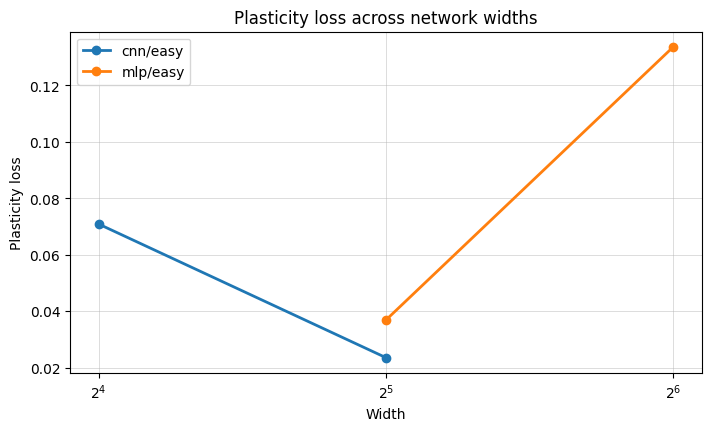

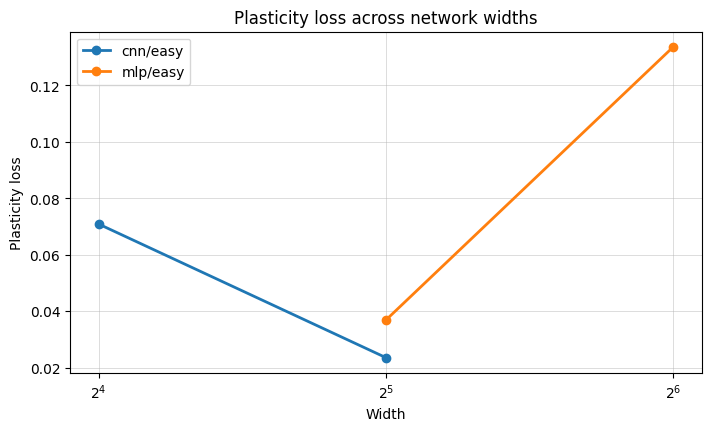

In [5]:
figure_path = OUTPUT_ROOT / "figure5_width_sweep.png"
fig = plot_width_sweep(width_df, save_path=figure_path)
fig

## Appendix A.2 Width Factors

In [6]:
# paper_configs = make_width_sweep_configs(
#     data_root=str(DATA_ROOT),
#     download=False,
#     architectures=("mlp", "cnn"),
#     environments=("easy", "hard", "sparse"),
#     base_width=16,
#     factors=(1, 2, 4, 8, 12, 16),
# )
# len(paper_configs), paper_configs[0]